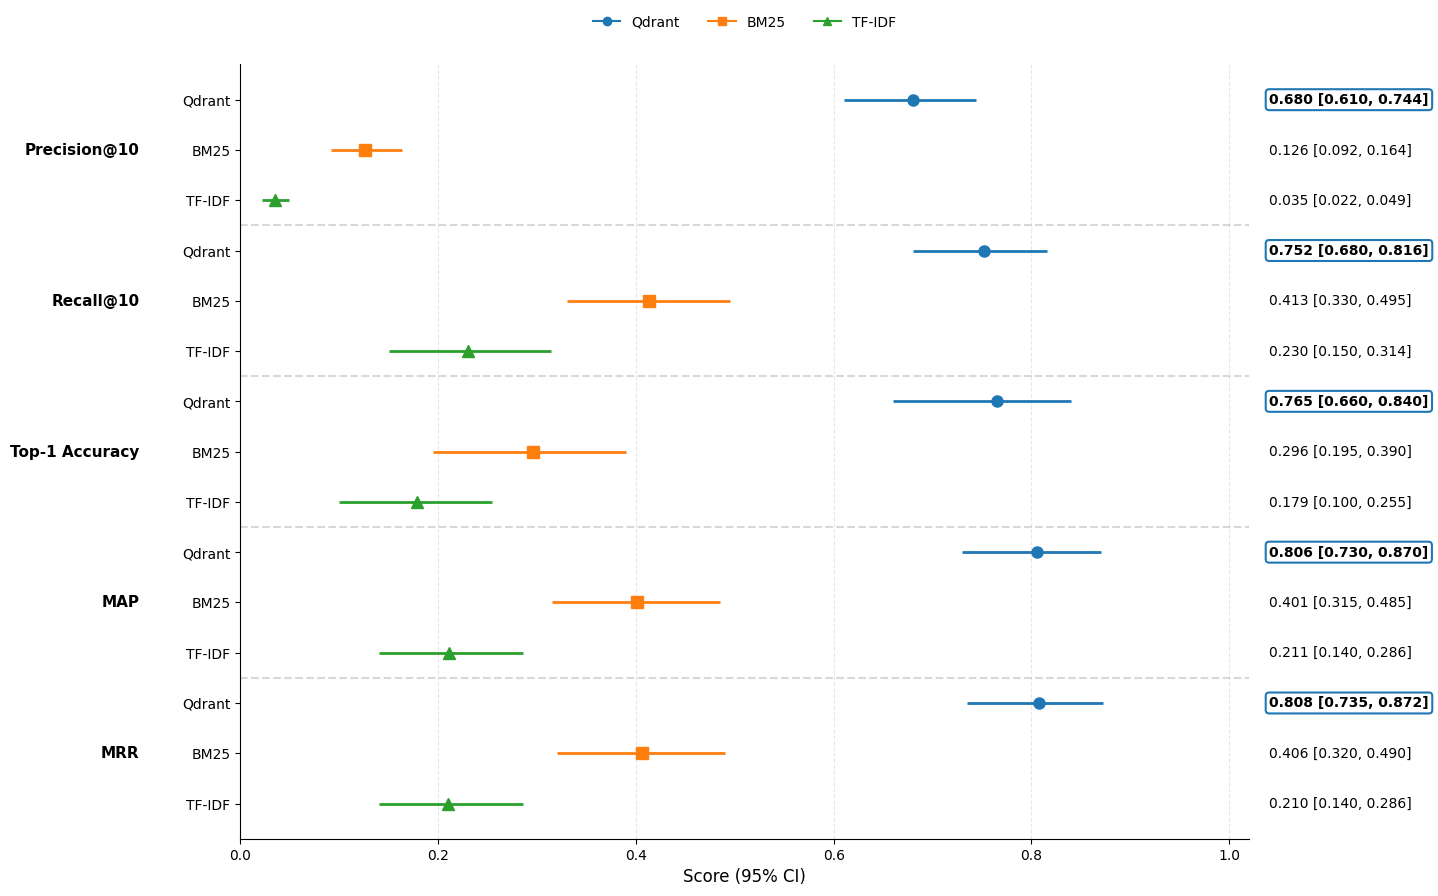

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =========================
# DATOS
# =========================
rows = [
    ("Qdrant", "Precision@10", 0.680, 0.610, 0.744),
    ("BM25", "Precision@10", 0.126, 0.092, 0.164),
    ("TF-IDF", "Precision@10", 0.035, 0.022, 0.049),

    ("Qdrant", "Recall@10", 0.752, 0.680, 0.816),
    ("BM25", "Recall@10", 0.413, 0.330, 0.495),
    ("TF-IDF", "Recall@10", 0.230, 0.150, 0.314),

    ("Qdrant", "Top-1 Accuracy", 0.765, 0.660, 0.840),
    ("BM25", "Top-1 Accuracy", 0.296, 0.195, 0.390),
    ("TF-IDF", "Top-1 Accuracy", 0.179, 0.100, 0.255),

    ("Qdrant", "MAP", 0.806, 0.730, 0.870),
    ("BM25", "MAP", 0.401, 0.315, 0.485),
    ("TF-IDF", "MAP", 0.211, 0.140, 0.286),

    ("Qdrant", "MRR", 0.808, 0.735, 0.872),
    ("BM25", "MRR", 0.406, 0.320, 0.490),
    ("TF-IDF", "MRR", 0.210, 0.140, 0.286),
]

# =========================
# ESTILOS
# =========================
colors = {
    "Qdrant": "#1f77b4",
    "BM25": "#ff7f0e",
    "TF-IDF": "#2ca02c",
}

markers = {
    "Qdrant": "o",
    "BM25": "s",
    "TF-IDF": "^",
}

# =========================
# AGRUPAR POR MÉTRICA
# =========================
grouped = defaultdict(list)
for method, metric, mean, low, high in rows:
    grouped[metric].append((method, mean, low, high))

metric_order = [
    "Precision@10",
    "Recall@10",
    "Top-1 Accuracy",
    "MAP",
    "MRR",
]

plot_data = []
y_labels = []
best_indices = []
separators = []
metric_positions = {}

idx = 0

for metric in metric_order:
    group = sorted(grouped[metric], key=lambda x: x[1], reverse=True)
    best_method = group[0][0]
    metric_positions[metric] = []

    for method, mean, low, high in group:
        plot_data.append((method, metric, mean, low, high))
        y_labels.append(method)
        metric_positions[metric].append(idx)

        if method == best_method:
            best_indices.append(idx)

        idx += 1

    separators.append(idx - 0.5)

# =========================
# PLOT
# =========================
y = np.arange(len(plot_data))[::-1]
fig, ax = plt.subplots(figsize=(14, 9))

for i, (method, metric, mean, low, high) in enumerate(plot_data):
    yy = y[i]

    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[method],
        color=colors[method],
        markersize=8,
        linewidth=2,
    )

    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold" if i in best_indices else "normal",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=colors[method],
            linewidth=1.5,
        ) if i in best_indices else None,
    )

# =========================
# HEADERS DE MÉTRICA
# =========================
for metric, indices in metric_positions.items():
    y_pos = np.mean([y[i] for i in indices])

    ax.text(
        -0.10,
        y_pos,
        metric,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# Separadores
for sep in separators[:-1]:
    ax.axhline(y=sep, color="gray", linestyle="--", alpha=0.3)

# =========================
# CONFIGURACIÓN
# =========================
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=10)

ax.set_xlabel("Score (95% CI)", fontsize=12)
ax.set_xlim(0.0, 1.02)

ax.grid(axis="x", linestyle="--", alpha=0.3)

for method in colors:
    ax.plot([], [], marker=markers[method], color=colors[method], label=method)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.32, right=0.75)

plt.tight_layout()
plt.savefig("8_rag_low.png", dpi=300, bbox_inches="tight")
plt.show()